In [1]:
# Track notebook start time
import time

notebook_start_time = time.time()

# EDA: Swire Coca‑Cola

- Authors: Ali Ladha, Cyrus Sobhani, Robby Stohel, and Sterling LeDuc 
- Date: 2025-10-04




# Introduction

Cart abandonment represents a significant challenge for digital ordering platforms, directly affecting both revenue and customer retention. For MyCoke360, Coca-Cola’s B2B digital ordering platform launched in summer 2024 by Swire Coca-Cola (Swire), understanding the behavioral and operational factors that contribute to incomplete purchases is essential. The platform serves Foodservice On-Premise (FSOP) customers such as restaurants, schools, hospitals, and retailers, where order frequency, timing, and product mix are key drivers of business performance. This exploratory analysis combines Google Analytics behavioral data with order and sales records to identify the patterns and conditions under which carts are abandoned. The goal is to provide actionable insights that support strategic interventions to improve order completion rates and customer engagement.


## Business Problem

Swire experiences measurable revenue loss each order cycle due to cart abandonment, where customers add products to their carts but fail to submit orders by the designated cutoff. This behavior not only results in missed sales opportunities but also disrupts plant logistics, complicates demand forecasting, and weakens customer relationships within the FSOP channel. Addressing this issue requires a data-driven understanding of the underlying behaviors, temporal trends, and operational factors that influence abandonment, enabling Swire to design targeted solutions that reduce financial loss and enhance platform efficiency.



## Initial Guiding Questions

- Which behavioral events or sequences of events are the strongest predictors of cart abandonment?
- What specific behaviors or conditions lead customers to return and complete a previously abandoned cart?
- What actions typically occur after a cart is abandoned? Do customers complete their purchase through another channel, or do they churn?
- What is the financial impact of cart abandonment on overall MyCoke360 revenue and product mix?
- Which products appear most frequently in abandoned carts?
- How does cart abandonment vary by device type, and what strategies can reduce it?

While these guiding questions move closer to addressing the main problem of the project, the exploratory data analysis may not answer them directly. Instead, they will serve to guide how the data is structured, organized, and prepared so that later modeling and analysis can properly evaluate the impact of cart abandonment.

## Individual Contributions

- Ali Ladha: 
- Cyrus Sobhani: 
- Robby Stohel: 
- Sterling LeDuc: 

## Initial Setup

In [2]:
# Imports
import os
import builtins
import datetime

from collections import defaultdict
from functools import reduce
from typing import Dict, List, Tuple, Optional
from functools import reduce as py_reduce
from datetime import timedelta

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import pandas as pd

from pyspark.sql import DataFrame, Row, SparkSession
from pyspark.sql.functions import *
from pyspark.sql.functions import (
    sum as sum_,
    count as count_,
    min as min_,
    max as max_,
    round as round_
)
from pyspark.sql.types import *


round = builtins.round

os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"
spark = (
    SparkSession.builder
    .appName("Capstone EDA")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
    .config("spark.sql.adaptive.skewJoin.enabled", "true")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.sql.autoBroadcastJoinThreshold", "134217728")  # 128 MB
    .config("spark.sql.files.maxPartitionBytes", "64m")
    .config("spark.sql.session.timeZone", "UTC")
    .getOrCreate()
)

# Set log level
spark.sparkContext.setLogLevel("ERROR")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/11 17:38:55 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## Helper Functions

In [3]:
def read_csv_reformat(path: str) -> DataFrame:
    """Read CSV with permissive parsing and snake_case columns."""
    # Read CSV with permissive parsing
    data_df = spark.read.csv(
        path,
        header=True,
        inferSchema=False,
        quote='"',
        escape='"',
        multiLine=True,
    )

    # Normalize column names
    fixed_cols = [c.strip().lower().replace(" ", "_") for c in data_df.columns]

    # Return DataFrame with normalized columns
    return data_df.toDF(*fixed_cols)


def summarize_datasets(dataset_map: Dict[str, DataFrame]) -> DataFrame:
    """Summarize tables with null-like counts and date/timestamp quantiles."""
    # Helpers for safe parsing and formatting
    def _to_float_or_none(s: str) -> Optional[float]:
        """Convert string to float or return None if invalid"""
        if s is None:
            return None
        v = str(s).strip()
        if v == "":
            return None
        try:
            return float(v)
        except Exception:
            return None

    def _fmt_epoch_date(x: Optional[float]) -> str:
        """Format epoch seconds as date"""
        if x is None:
            return ""
        return datetime.datetime.fromtimestamp(x).date().isoformat()

    def _fmt_epoch_ts(x: Optional[float]) -> str:
        """Format epoch seconds as timestamp"""
        if x is None:
            return ""
        return datetime.datetime.fromtimestamp(x).strftime("%Y-%m-%d %H:%M:%S")

    # Define desired metric order
    metric_order = [
        "count",
        "mean",
        "stddev",
        "min",
        "25%",
        "50%",
        "75%",
        "max",
        "null_like",
    ]

    # Prepare accumulator for wide rows
    records: List[Tuple] = []

    # Iterate each table
    for table_name, table_df in dataset_map.items():
        # Identify date and timestamp columns
        date_cols: List[str] = []
        ts_cols: List[str] = []
        for field in table_df.schema.fields:
            if isinstance(field.dataType, DateType):
                date_cols.append(field.name)
            elif isinstance(field.dataType, TimestampType):
                ts_cols.append(field.name)

        # Build DataFrame for summary() with epoch for date/timestamps
        select_exprs = []
        for col_name in table_df.columns:
            if col_name in date_cols or col_name in ts_cols:
                ts_cast = col(col_name).cast("timestamp")
                epoch_alias = unix_timestamp(ts_cast).alias(col_name)
                select_exprs.append(epoch_alias)
            else:
                select_exprs.append(col(col_name))
        df_for_summary = table_df.select(*select_exprs)

        # Run summary on transformed DataFrame
        raw_summary_df = df_for_summary.summary()
        raw_maps = [r.asDict() for r in raw_summary_df.collect()]

        # Build metric -> {column -> value} map
        metric_map: Dict[str, Dict[str, str]] = {}
        for row_map in raw_maps:
            m_name = str(row_map.get("summary"))
            metric_map[m_name] = {}
            for col_name in table_df.columns:
                val = row_map.get(col_name)
                metric_map[m_name][col_name] = "" if val is None else str(val)

        # Convert epoch stats back for date/timestamp columns
        to_fix_stats = ["min", "25%", "50%", "75%", "max", "mean"]
        for col_name in date_cols:
            for stat in to_fix_stats:
                raw = metric_map.get(stat, {}).get(col_name, "")
                num = _to_float_or_none(raw)
                if stat in metric_map:
                    metric_map[stat][col_name] = _fmt_epoch_date(num)
        for col_name in ts_cols:
            for stat in to_fix_stats:
                raw = metric_map.get(stat, {}).get(col_name, "")
                num = _to_float_or_none(raw)
                if stat in metric_map:
                    metric_map[stat][col_name] = _fmt_epoch_ts(num)

        # Build null-like aggregations on the original DataFrame
        null_exprs = []
        for col_name in table_df.columns:
            dtype = table_df.schema[col_name].dataType
            empty_like = col(col_name).isNull()
            if isinstance(dtype, StringType):
                empty_like = empty_like | (col(col_name) == "")
                empty_like = empty_like | (lower(col(col_name)) == "null")
            if isinstance(dtype, ArrayType):
                empty_like = empty_like | (size(col(col_name)) == 0)
            agg_col = sum_(when(empty_like, lit(1)).otherwise(lit(0))).alias(
                col_name
            )
            null_exprs.append(agg_col)

        # Collect null-like counts
        null_like_row = table_df.agg(*null_exprs).collect()[0].asDict()

        # Assemble wide rows per column
        for col_name in table_df.columns:
            vals = []
            for m in metric_order:
                if m != "null_like":
                    vals.append(metric_map.get(m, {}).get(col_name, ""))
                else:
                    vals.append(str(null_like_row.get(col_name, "")))
            records.append((table_name, col_name, *vals))

    # Create output schema and DataFrame
    first_df = next(iter(dataset_map.values()))

    out_fields: List[StructField] = [
        StructField("table", StringType()),
        StructField("column", StringType()),
    ]
    for m in metric_order:
        out_fields.append(StructField(m, StringType()))
    out_schema = StructType(out_fields)

    # Build final result and display
    display(spark.createDataFrame(records, out_schema))


def datatype_and_normalization_check(
    dataset_map: Dict[str, DataFrame], num_rows: int = 3
) -> None:
    """List table, column, and sample values."""
    # Build rows as (table, column, row_1, row_2, ...)
    out_rows: List[Tuple] = []
    for table_name, table_df in dataset_map.items():
        sample_rows = table_df.limit(num_rows).collect()
        if not sample_rows:
            out_rows.append((table_name, None, *([None] * num_rows)))
            continue
        sample_maps = [r.asDict() for r in sample_rows]
        for col_name in table_df.columns:
            vals = [
                str(sample_maps[i].get(col_name))
                if i < len(sample_maps)
                else None
                for i in range(num_rows)
            ]
            out_rows.append((table_name, col_name, *vals))

    # Build schema dynamically
    schema_fields = [
        StructField("table", StringType()),
        StructField("column", StringType()),
    ] + [StructField(f"row_{i + 1}", StringType()) for i in range(num_rows)]
    out_schema = StructType(schema_fields)

    # Create result DataFrame and display
    display(spark.createDataFrame(out_rows, out_schema))


def missing_check(dataset_map: Dict[str, DataFrame]) -> None:
    """Count missing indicators per column with type safety."""
    # Prepare output rows
    out_rows: List[
        Tuple[str, str, int, int, int, int, int, int, float]
    ] = []

    # Iterate tables
    for table_name, table_df in dataset_map.items():
        agg_exprs = []

        # Build per-column aggregations
        for field in table_df.schema.fields:
            col_name = field.name
            dtype = field.dataType

            # Count nulls
            agg_exprs.append(
                sum_(when(col(col_name).isNull(), 1).otherwise(0)).alias(
                    f"{col_name}__null"
                )
            )

            # Count NaNs for floats/doubles
            if isinstance(dtype, (FloatType, DoubleType)):
                agg_exprs.append(
                    sum_(when(isnan(col(col_name)), 1).otherwise(0)).alias(
                        f"{col_name}__nan"
                    )
                )
            else:
                agg_exprs.append(sum_(lit(0)).alias(f"{col_name}__nan"))

            # Count empty strings and literal "null" for strings
            if isinstance(dtype, StringType):
                agg_exprs.append(
                    sum_(when(col(col_name) == "", 1).otherwise(0)).alias(
                        f"{col_name}__empty"
                    )
                )
                agg_exprs.append(
                    sum_(
                        when(lower(col(col_name)) == "null", 1).otherwise(0)
                    ).alias(f"{col_name}__literal_null")
                )
            else:
                agg_exprs.append(sum_(lit(0)).alias(f"{col_name}__empty"))
                agg_exprs.append(
                    sum_(lit(0)).alias(f"{col_name}__literal_null")
                )

            # Count empty arrays for arrays
            if isinstance(dtype, ArrayType):
                agg_exprs.append(
                    sum_(when(size(col(col_name)) == 0, 1).otherwise(0)).alias(
                        f"{col_name}__empty_array"
                    )
                )
            else:
                agg_exprs.append(
                    sum_(lit(0)).alias(f"{col_name}__empty_array")
                )

        # Add row count
        agg_exprs.append(count_(lit(1)).alias("__rows"))

        # Compute stats
        stats = table_df.agg(*agg_exprs).first().asDict()
        total_rows = int(stats.get("__rows", 0))

        # Build per-column rows
        for col_name in table_df.columns:
            c_null = int(stats.get(f"{col_name}__null", 0))
            c_nan = int(stats.get(f"{col_name}__nan", 0))
            c_empty = int(stats.get(f"{col_name}__empty", 0))
            c_literal = int(stats.get(f"{col_name}__literal_null", 0))
            c_empty_arr = int(stats.get(f"{col_name}__empty_array", 0))
            c_total = c_null + c_nan + c_empty + c_literal + c_empty_arr
            p_missing = round(c_total / total_rows, 4) if total_rows else 0.0
            out_rows.append(
                (
                    table_name,
                    col_name,
                    c_null,
                    c_nan,
                    c_empty,
                    c_literal,
                    c_empty_arr,
                    c_total,
                    p_missing,
                )
            )

    # Build schema
    out_schema = StructType(
        [
            StructField("table", StringType()),
            StructField("column", StringType()),
            StructField("null_count", LongType()),
            StructField("nan_count", LongType()),
            StructField("empty_string_count", LongType()),
            StructField("literal_null_count", LongType()),
            StructField("empty_array_count", LongType()),
            StructField("total_missing", LongType()),
            StructField("missing_prop", DoubleType()),
        ]
    )

    # Create DataFrame and display
    display(spark.createDataFrame(out_rows, out_schema))


def side_by_side_uniques(
    table_df: DataFrame, col_names: List[str]
) -> None:
    """Return distinct values side-by-side with '' padding."""
    # Cast to string for display
    casted_df = table_df.select(
        *[col(c).cast(StringType()).alias(c) for c in col_names]
    )

    # Detect if each column contains a real null
    has_null_exprs = [
        max_(when(col(c).isNull(), lit(1)).otherwise(lit(0))).alias(
            f"{c}__has_null"
        )
        for c in col_names
    ]

    # Aggregate sorted unique arrays per column
    agg_exprs = [sort_array(collect_set(col(c))).alias(c) for c in col_names]
    agg_df = casted_df.agg(*agg_exprs, *has_null_exprs)

    # Append a real null to arrays when present
    for c in col_names:
        agg_df = (
            agg_df.withColumn(
                c,
                when(
                    col(f"{c}__has_null") == 1,
                    concat(col(c), array(lit(None).cast(StringType()))),
                ).otherwise(col(c)),
            )
            .withColumn(f"{c}__size", size(col(c)))
        )

    # Zip arrays positionally
    zipped_df = agg_df.select(
        arrays_zip(*[col(c) for c in col_names]).alias("zipped"),
        *[col(f"{c}__size").alias(f"{c}__size") for c in col_names],
    )

    # Explode to rows with position index
    exploded_df = zipped_df.select(
        posexplode(col("zipped")).alias("rn", "row_struct"),
        *[col(f"{c}__size") for c in col_names],
    )

    # Pad with '' when row index exceeds column size
    result_df = exploded_df.select(
        *[
            when(col(f"{c}__size") > col("rn"), col(f"row_struct.`{c}`"))
            .otherwise(lit(""))
            .alias(c)
            for c in col_names
        ]
    )

    # Display result dataframe
    display(result_df)


def add_ts_utc_by_location(
    table_df: DataFrame,
    tz_map: Dict[str, str],
    date_col_name: str,
    location_col_name: str = "sales_office_location",
) -> DataFrame:
    """Convert a local date to UTC using a location-to-timezone mapping."""
    # Group locations by time zone
    tz_groups: Dict[str, List[str]] = defaultdict(list)
    for location, tz_name in tz_map.items():
        tz_groups[tz_name].append(location)

    # Convert local date to timestamp
    temp_df = table_df.withColumn("local_ts", to_timestamp(col(date_col_name)))

    # Start with default UTC conversion
    utc_expr = to_utc_timestamp(col("local_ts"), "UTC")

    # Layer timezone-specific branches
    for tz_name, loc_list in tz_groups.items():
        utc_expr = when(
            col(location_col_name).isin(loc_list),
            to_utc_timestamp(col("local_ts"), tz_name),
        ).otherwise(utc_expr)

    # Build output column name
    output_col = f"{date_col_name.replace('date', 'ts')}_utc"

    # Finalize DataFrame with UTC column added and return
    return temp_df.withColumn(output_col, utc_expr).drop("local_ts")


def extract_dtype_dfs(df: DataFrame, dtypes: List[str]) -> DataFrame:
    """Select columns matching specified dtypes, excluding ID fields."""
    # Filter out ID columns and keep only matching data types
    selected_cols = [
        col_name for col_name, dt in df.dtypes if dt in dtypes and "_id" not in col_name
    ]

    # Return DataFrame with selected columns
    return df.select(selected_cols)

# Data Description

The dataset consists of eight CSV tables covering customer behavior, transactions, and supporting reference information. Three fact tables capture activity on MyCoke360: Google Analytics events (site visits, add/remove cart actions, purchases, and device/page details), Orders (materials ordered per customer, with order type and timestamps in both EST and UTC), and Sales (fulfilled transactions with pricing and profit measures). These are complemented by five dimension tables: Customer (account and channel attributes, sales office details), Cutoff Times (order cutoff policies by plant, office, and distribution mode), Material (product master data such as pack type, brand, flavor, and category), Operating Hours (current ordering frequency and anchor day/date by customer), and Visit Plan (historical anchor dates, frequencies, and sales office attributes). Collectively, these tables create a comprehensive view of both customer behavior and business processes adequetely enabling our analysis.

## Data Limitations

Incomplete GA event capture - Google Analytics (GA) may drop or fail to record some events, particularly for high-volume or mobile traffic sessions. As a result, purchase events may be missing, creating false positives for abandoned carts.

Data mismatches across systems - There may be discrepancies between GA-reported add_to_cart and purchase events and the corresponding entries in the Orders and Sales systems. These inconsistencies could arise from asynchronous processing, caching, or API latency.

Mobile event data gaps - Mobile purchase events sometimes lack complete item-level detail, resulting in blank product identifiers or incomplete material-level mappings. This limits the accuracy of per-material revenue attribution and product-mix analysis.

Attribution ambiguity - In cases where a customer purchases via a different channel (e.g., through a sales representative or direct order portal), GA may not capture that completion, leading to potential overestimation of abandonment rates.

Temporal alignment challenges - Differences in time zone handling, cutoff times, and event timestamp granularity may introduce misalignment when constructing order windows and evaluating cross-day behaviors.

## Calculation Rules

Define order windows by sales office - Construct order windows based on each office's anchor date and ordering frequency, applying the corresponding local cutoff time to ensure temporal consistency across time zones and business schedules.

Identify cart abandonment events - Classify a cart as abandoned if items were added within an order window but no corresponding purchase occurred during that same window. Use the orders table to override abandonment flags when legitimate purchases are later identified outside of the event stream.

Calculate per-material revenue estimates - Derive material-level revenue values by combining transaction-level data from sales with daily average prices, which fluctuate by day and customer. This ensures accurate alignment between behavioral events (from GA) and transactional outcomes (from Orders/Sales systems).

Align behavioral and transactional datasets - Ensure that GA event data (add_to_cart, purchase, etc.) is synchronized with transactional records from the orders and sales tables to resolve timing differences or missing events before determining abandonment status.

## Data Loading & Structure

In [4]:
# Define base data directory relative to the current notebook
base_dir = os.path.join(os.getcwd(), "data")


# Fact tables
google_analytics = read_csv_reformat(
    os.path.join(base_dir, "google_analytics.csv")
)
orders = read_csv_reformat(
    os.path.join(base_dir, "orders.csv")
)
sales = read_csv_reformat(
    os.path.join(base_dir, "sales.csv")
)


# Dimension tables
customers = read_csv_reformat(
    os.path.join(base_dir, "customer.csv")
)
materials = read_csv_reformat(
    os.path.join(base_dir, "material.csv")
)
operating_hours = read_csv_reformat(
    os.path.join(base_dir, "operating_hours.csv")
)
visit_plan = read_csv_reformat(
    os.path.join(base_dir, "visit_plan.csv")
)
cutoff_times = read_csv_reformat(
    os.path.join(base_dir, "cutoff_times.csv")
)

datasets = {
    "google_analytics": google_analytics,
    "orders": orders,
    "sales": sales,
    "customers": customers,
    "materials": materials,
    "operating_hours": operating_hours,
    "visit_plan": visit_plan,
    "cutoff_times": cutoff_times,
}

In [5]:
# Display row and column counts for each dataset
for dataset_name, dataset_df in datasets.items():
    row_count = dataset_df.count()
    col_count = len(dataset_df.columns)
    print(
        f"{dataset_name.replace('_', ' ').title()}: "
        f"{row_count} rows, {col_count} columns"
    )

# Display dataset summary
summarize_datasets(datasets)

Google Analytics: 3704088 rows, 10 columns
Orders: 1662157 rows, 7 columns
Sales: 499787 rows, 6 columns
Customers: 6334 rows, 7 columns
Materials: 1252 rows, 6 columns
Operating Hours: 6202 rows, 4 columns


Visit Plan: 13638683 rows, 9 columns
Cutoff Times: 220 rows, 5 columns


DataFrame[table: string, column: string, count: string, mean: string, stddev: string, min: string, 25%: string, 50%: string, 75%: string, max: string, null_like: string]

# Transformation & Cleaning

This section outlines the transformation and cleaning steps that produce a reliable analytical dataset ready for modeling and interpretation. It begins with data typing and normalization, where each field is aligned to an appropriate type, categorical levels are standardized, and numeric scales are normalized when necessary to improve comparability. Next, missing values are profiled to understand their patterns and likely mechanisms, followed by targeted treatments such as imputation, selective exclusion, or indicator columns, with all assumptions documented. Outlier detection then identifies anomalous observations using standard visuals, and outcomes are reviewed to determine whether values should be retained, capped, transformed, or removed. Throughout, intermediate results are visualized and interpreted in context so that choices remain transparent and defensible. All transformations are applied reproducibly, with clear notes on rationale and impact, ensuring the final dataset reflects consistent definitions, stable units, and trustworthy structure for subsequent analysis.


## Data Typing & Normalization

In [6]:
# Display datatype and normalization check for each dataset (showing two rows)
datatype_and_normalization_check(datasets, num_rows=2)

DataFrame[table: string, column: string, row_1: string, row_2: string]

### Initial Observations

#### Google Analytics

- Treat customer_id as an identifier and cast it to IntegerType; ignore any leading zeros used for warehouse formatting.
- Cast event_date from ISO-style strings (yyyy-MM-dd) to DateType.
- Cast event_timestamp from full ISO strings with a Z suffix to TimestampType, and confirm the source timezone so it can be converted to UTC if needed.
- Parse items as JSON arrays using from_json.
- Normalize device_category values such as “mobile” and “desktop” to consistent capitalization.
- Keep device_mobile_brand_name as mixed case (for example, “Samsung” and “Google”) and note that no nulls were observed.
- Keep device_operating_system as mixed case (for example, “Android” and “Windows”) and note that no nulls were observed.
- Replace blank event_page_name entries with nulls.
- Replace blank event_page_title entries with nulls.

#### Orders

- Cast customer_id to IntegerType and ignore leading zeros used for formatting.
- Cast material_id to IntegerType and ignore leading zeros used for formatting.
- Cast order_quantity to DoubleType.
- Cast created_date_utc from ISO strings to TimestampType.
- Drop created_date_est and retain created_date_utc as the standard.
- Standardize order_type by converting to lowercase and replacing spaces with underscores.

#### Sales

- Cast posting_date from M/d/yyyy strings to DateType.
- Cast customer_id to IntegerType and ignore leading zeros.
- Cast material_id to IntegerType and ignore leading zeros.
- Cast gross_profit_dead_net to DoubleType.
- Cast physical_volume to DoubleType.
- Cast nsi_dead_net to DoubleType.

#### Customers

- Derive customer_id from customer_number and cast it to IntegerType.
- Convert shipping_conditions_description to lowercase for consistency.
- Standardize cold_drink_channel_description categories such as “48 Hours” using a controlled mapping.
- Format customer_sub_trade_channel_description with InitCap for readable display.
- Remap distribution_mode_description categories such as “Sideload” to standardized codes.

#### Materials

- Cast material_id to IntegerType and ignore leading zeros.
- Rename trade_mark_desc to trademark for clarity.
- Rename flavour_desc to flavor for consistent spelling.
- Rename bev_cat_desc to beverage_category for clarity.
- Rename pack_type_desc to packaging_type for consistency.
- Rename pack_size_desc to packaging_size for consistency.

#### Operating Hours

- Cast customer_id to IntegerType and ignore leading zeros.
- Cast calling_anchor_date from M/d/yyyy strings to DateType.
- Remap frequency codes such as “E”, “2”, “3”, and “4” to numeric day intervals.

#### Visit Plan

- Cast customer_id to IntegerType and ignore leading zeros.
- Remap shipping_conditions_desc categories such as “48 Hours” to standardized durations.
- Confirm distribution_mode values and standardize their casing.
- Remap frequency values such as “01” and “02 to day equivalents.
- Replace the literal text "null" in sales_office with actual null values.
- Replace the literal text "null" in sales_office_desc with actual null values.
- Cast anchor_date from ISO-style strings to DateType.
- Cast elt_ts from ISO strings with a Z suffix to TimestampType, and convert from EST to UTC as appropriate.
- Cast snapshot_date from ISO-style strings to DateType.

#### Cutoff Times

- Remap distribution_mode to standardized short codes and enforce consistent casing.
- Rename shipping_condition_time to shipping_duration and ensure a numeric or duration type.
- Rename cutofftime__c to cutoff_time and ensure a time or duration type.

#### Additional Notes

- Normalize both true nulls and string literals such as "null" to consistent null representations.
- Standardize categorical values to eliminate hidden casing variations.
- Review and validate the two client-provided mapping tables before applying them.
- Use the existing helper functions to support and streamline the normalization workflow.

### Google Analytics

In [7]:
# Choose categorical columns to compare side-by-side
category_cols: List[str] = [
    "event_page_title",
    "event_page_name",
    "event_name",
    "device_category",
    "device_mobile_brand_name",
    "device_operating_system",
]

# Show side-by-side distinct values
side_by_side_uniques(datasets["google_analytics"], category_cols)

DataFrame[event_page_title: string, event_page_name: string, event_name: string, device_category: string, device_mobile_brand_name: string, device_operating_system: string]

In [8]:
# Define schema for parsed items array
items_schema: ArrayType = ArrayType(
    StructType(
        [
            StructField("item_id", StringType()),
            StructField("quantity", StringType()),
        ]
    )
)

# Clean and standardize google_analytics dataset
datasets["google_analytics"] = (
    datasets["google_analytics"]
    # Cast and parse key fields
    .withColumn("customer_id", col("customer_id").cast("int"))
    .withColumn("event_date", to_date("event_date", "yyyy-MM-dd"))
    # Parse event timestamp with timezone-aware pattern
    .withColumn(
        "event_ts_utc",
        to_timestamp(col("event_timestamp"), "yyyy-MM-dd'T'HH:mm:ss.SSSX"),
    )
    # Parse items JSON into structured array
    .withColumn("items", from_json(col("items"), items_schema))
    # Drop placeholder '(not set)' items and null out empty results
    .withColumn(
        "items",
        when(
            size(expr("filter(`items`, x -> x.item_id != '(not set)')")) == 0,
            None,
        ).otherwise(expr("filter(`items`, x -> x.item_id != '(not set)')")),
    )
    # Normalize null-like strings to real nulls
    .withColumn(
        "device_mobile_brand_name",
        when(trim(lower(col("device_mobile_brand_name"))) == "null", None).otherwise(
            col("device_mobile_brand_name")
        ),
    )
    .withColumn(
        "event_page_name",
        when(trim(lower(col("event_page_name"))) == "null", None).otherwise(
            col("event_page_name")
        ),
    )
    .withColumn(
        "event_page_title",
        when(trim(lower(col("event_page_title"))) == "null", None).otherwise(
            col("event_page_title")
        ),
    )
    # Apply case formatting for display fields
    .withColumn("event_name", lower(col("event_name")))
    .withColumn("device_category", initcap(col("device_category")))
    .withColumn("event_page_name", initcap(col("event_page_name")))
    .withColumn("event_page_title", initcap(col("event_page_title")))
    # Select final columns and order rows
    .select(
        "customer_id",
        "event_name",
        "device_category",
        "device_mobile_brand_name",
        "device_operating_system",
        "event_page_name",
        "event_page_title",
        "items",
        "event_date",
        "event_ts_utc",
    )
    .orderBy("customer_id", "event_ts_utc")
)

# Preview cleaned data and schema
display(datasets["google_analytics"].limit(3))
datasets["google_analytics"].printSchema()

DataFrame[customer_id: int, event_name: string, device_category: string, device_mobile_brand_name: string, device_operating_system: string, event_page_name: string, event_page_title: string, items: array<struct<item_id:string,quantity:string>>, event_date: date, event_ts_utc: timestamp]

root
 |-- customer_id: integer (nullable = true)
 |-- event_name: string (nullable = true)
 |-- device_category: string (nullable = true)
 |-- device_mobile_brand_name: string (nullable = true)
 |-- device_operating_system: string (nullable = true)
 |-- event_page_name: string (nullable = true)
 |-- event_page_title: string (nullable = true)
 |-- items: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- item_id: string (nullable = true)
 |    |    |-- quantity: string (nullable = true)
 |-- event_date: date (nullable = true)
 |-- event_ts_utc: timestamp (nullable = true)



### Orders

In [9]:
# Choose categorical columns to compare side-by-side
category_cols: List[str] = ["order_type"]

# Show side-by-side distinct values
side_by_side_uniques(datasets["orders"], category_cols)

DataFrame[order_type: string]

In [10]:
# Standardize and cast order dataset fields
datasets["orders"] = (
    datasets["orders"]
    # Cast numeric and timestamp fields
    .withColumn("customer_id", col("customer_id").cast("int"))
    .withColumn("material_id", col("material_id").cast("int"))
    .withColumn("order_quantity", col("order_quantity").cast("double"))
    .withColumn(
        "created_ts_utc",
        to_timestamp(col("created_date_utc"), "yyyy-MM-dd'T'HH:mm:ss.SSSX"),
    )
    # Normalize order type to lowercase and underscore-separated format
    .withColumn(
        "order_type",
        lower(regexp_replace("order_type", " ", "_")),
    )
    # Replace null-like values in plant_id with actual nulls
    .withColumn(
        "plant_id",
        when(trim(lower(col("plant_id"))) == "null", None).otherwise(
            col("plant_id")
        ),
    )
    # Select final columns with standardized naming
    .select(
        "customer_id",
        "material_id",
        col("plant_id").alias("sales_office_id"),
        "order_quantity",
        "order_type",
        "created_ts_utc",
    )
)

# Preview cleaned dataset and schema
display(datasets["orders"].limit(3))
datasets["orders"].printSchema()

DataFrame[customer_id: int, material_id: int, sales_office_id: string, order_quantity: double, order_type: string, created_ts_utc: timestamp]

root
 |-- customer_id: integer (nullable = true)
 |-- material_id: integer (nullable = true)
 |-- sales_office_id: string (nullable = true)
 |-- order_quantity: double (nullable = true)
 |-- order_type: string (nullable = true)
 |-- created_ts_utc: timestamp (nullable = true)



### Sales

In [11]:
# Cast and standardize sales dataset
datasets["sales"] = (
    datasets["sales"]
    # Convert date and timestamp fields
    .withColumn("posting_date", to_date("posting_date", "M/d/yyyy"))
    .withColumn("posting_ts", to_timestamp(col("posting_date")))
    # Cast numeric identifiers
    .withColumn("customer_id", col("customer_id").cast("int"))
    .withColumn("material_id", col("material_id").cast("int"))
    # Convert financial fields to double
    .withColumn("gross_profit_dead_net", col("gross_profit_dead_net").cast("double"))
    .withColumn("physical_volume", col("physical_volume").cast("double"))
    .withColumn("nsi_dead_net", col("nsi_dead_net").cast("double"))
    # Compute derived unit price
    .withColumn("unit_price", col("nsi_dead_net") / col("physical_volume"))
    # Select final columns
    .select(
        "customer_id",
        "material_id",
        "physical_volume",
        "unit_price",
        col("nsi_dead_net").alias("revenue"),
        col("gross_profit_dead_net").alias("profit"),
        "posting_date",
        "posting_ts",
    )
)

# Preview cleaned sales data and schema
display(datasets["sales"].limit(3))
datasets["sales"].printSchema()

DataFrame[customer_id: int, material_id: int, physical_volume: double, unit_price: double, revenue: double, profit: double, posting_date: date, posting_ts: timestamp]

root
 |-- customer_id: integer (nullable = true)
 |-- material_id: integer (nullable = true)
 |-- physical_volume: double (nullable = true)
 |-- unit_price: double (nullable = true)
 |-- revenue: double (nullable = true)
 |-- profit: double (nullable = true)
 |-- posting_date: date (nullable = true)
 |-- posting_ts: timestamp (nullable = true)



### Customers

In [12]:
# Choose categorical columns to compare side-by-side
category_cols: List[str] = [
    "sales_office", "sales_office_description", "cold_drink_channel_description",
    "customer_sub_trade_channel_description", "distribution_mode_description"
]

# Show side-by-side distinct values
side_by_side_uniques(datasets["customers"], category_cols)

DataFrame[sales_office: string, sales_office_description: string, cold_drink_channel_description: string, customer_sub_trade_channel_description: string, distribution_mode_description: string]

In [13]:
# Define mapping for distribution modes
mode_map: Dict[str, str] = {
    "ofs": "of",
    "rapiddelivery": "rd",
    "epallet": "ez",
    "sideload": "sl",
    "nightsideload": "ns",
    "fullservice": "fs",
    "nightrapiddelivery": "nr",
    "nightofs": "no",
    "specialevents": "se",
    "bulkdistribution": "bk",
    "directstoredelivery": "dd",
    "tellsale": "ts",
}

# Clean and standardize customers dataset
datasets["customers"] = (
    datasets["customers"]
    # Convert customer_number to integer
    .withColumn("customer_id", col("customer_number").cast("int"))
    # Normalize and format text columns
    .withColumn(
        "shipping_conditions_description",
        lower(col("shipping_conditions_description")),
    )
    .withColumn(
        "cold_drink_channel_description",
        initcap(col("cold_drink_channel_description")),
    )
    .withColumn(
        "customer_sub_trade_channel_description",
        initcap(col("customer_sub_trade_channel_description")),
    )
    # Normalize distribution mode field
    .withColumn(
        "distribution_mode_description",
        lower(regexp_replace(col("distribution_mode_description"), " ", "")),
    )
    .withColumn(
        "distribution_mode",
        create_map([lit(x) for kv in mode_map.items() for x in kv])[
            col("distribution_mode_description")
        ],
    )
    # Derive shipping duration
    .withColumn(
        "shipping_duration",
        when(col("shipping_conditions_description").like("%24%"), lit("24hrs"))
        .when(col("shipping_conditions_description").like("%48%"), lit("48hrs"))
        .when(col("shipping_conditions_description").like("%72%"), lit("72hrs"))
        .otherwise(None),
    )
    # Derive shipping destination
    .withColumn(
        "shipping_destination",
        when(
            col("shipping_conditions_description").contains("dropsite"),
            lit("dropsite"),
        ).otherwise(lit("customer")),
    )
    # Select and rename final output columns
    .select(
        "customer_id",
        col("sales_office").alias("sales_office_id"),
        col("sales_office_description").alias("sales_office_location"),
        "cold_drink_channel_description",
        "customer_sub_trade_channel_description",
        "distribution_mode",
        "shipping_duration",
        "shipping_destination",
    )
)

# Preview cleaned data and schema
display(datasets["customers"].limit(3))
datasets["customers"].printSchema()

DataFrame[customer_id: int, sales_office_id: string, sales_office_location: string, cold_drink_channel_description: string, customer_sub_trade_channel_description: string, distribution_mode: string, shipping_duration: string, shipping_destination: string]

root
 |-- customer_id: integer (nullable = true)
 |-- sales_office_id: string (nullable = true)
 |-- sales_office_location: string (nullable = true)
 |-- cold_drink_channel_description: string (nullable = true)
 |-- customer_sub_trade_channel_description: string (nullable = true)
 |-- distribution_mode: string (nullable = true)
 |-- shipping_duration: string (nullable = true)
 |-- shipping_destination: string (nullable = false)



### Materials

In [14]:
# Choose categorical columns to compare side-by-side
category_cols: List[str] = [
    "pack_type_desc", "trade_mark_desc", "flavour_desc",
    "pack_size_desc", "bev_cat_desc"
]

# Show side-by-side distinct values
side_by_side_uniques(datasets["materials"], category_cols)

DataFrame[pack_type_desc: string, trade_mark_desc: string, flavour_desc: string, pack_size_desc: string, bev_cat_desc: string]

In [15]:
# Define mapping from verbose to short unit labels
metric_map: Dict[str, str] = {
    "ounce": "oz",
    "gallon": "gal",
    "pound": "lb",
    "gm": "g",
}

# Clean and standardize materials dataset
datasets["materials"] = (
    datasets["materials"]
    # Cast and normalize fields
    .withColumn("material_id", col("material_id").cast("int"))
    .withColumn("pack_size_desc", lower(col("pack_size_desc")))
    # Replace verbose unit names with short labels
    .withColumn(
        "pack_size_desc",
        py_reduce(
            lambda acc, kv: regexp_replace(acc, kv[0], kv[1]),
            metric_map.items(),
            col("pack_size_desc"),
        ),
    )
    # Select and rename final columns
    .select(
        "material_id",
        col("trade_mark_desc").alias("trademark"),
        col("flavour_desc").alias("flavor"),
        col("bev_cat_desc").alias("beverage_category"),
        col("pack_type_desc").alias("packaging_type"),
        col("pack_size_desc").alias("packaging_size"),
    )
)

# Preview cleaned data and schema
display(datasets["materials"].limit(3))
datasets["materials"].printSchema()

# Show categorical uniques side-by-side
category_cols: List[str] = [
    "packaging_type",
    "trademark",
    "flavor",
    "packaging_size",
    "beverage_category",
]
display(side_by_side_uniques(datasets["materials"], category_cols))

DataFrame[material_id: int, trademark: string, flavor: string, beverage_category: string, packaging_type: string, packaging_size: string]

root
 |-- material_id: integer (nullable = true)
 |-- trademark: string (nullable = true)
 |-- flavor: string (nullable = true)
 |-- beverage_category: string (nullable = true)
 |-- packaging_type: string (nullable = true)
 |-- packaging_size: string (nullable = true)



DataFrame[packaging_type: string, trademark: string, flavor: string, packaging_size: string, beverage_category: string]

None

### Operating Hours

In [16]:
# Choose categorical columns to compare side-by-side
category_cols: List[str] = [
    "frequency", "delivery_anchor_day"
]

# Show side-by-side distinct values
side_by_side_uniques(datasets["operating_hours"], category_cols)

DataFrame[frequency: string, delivery_anchor_day: string]

In [17]:
# Cast and clean operating_hours dataset
datasets["operating_hours"] = (
    datasets["operating_hours"]
    # Convert key columns to appropriate types
    .withColumn("customer_id", col("customer_number").cast("int"))
    .withColumn(
        "calling_anchor_date",
        to_date("calling_anchor_date", "M/d/yyyy"),
    )
    # Normalize frequency values to numeric cycle lengths
    .withColumn(
        "frequency",
        when(col("frequency").like("%4%"), lit(28))
        .when(col("frequency").like("%3%"), lit(21))
        .when(col("frequency").like("%2%"), lit(14))
        .when(col("frequency").like("%E%"), lit(7))
        .otherwise(None),
    )
    # Select and rename key fields
    .select(
        "customer_id",
        "frequency",
        col("delivery_anchor_day").alias("delivery_day_of_week_name"),
        col("calling_anchor_date").alias("anchor_date"),
    )
)

# Preview cleaned dataset
display(datasets["operating_hours"].limit(3))
datasets["operating_hours"].printSchema()

DataFrame[customer_id: int, frequency: int, delivery_day_of_week_name: string, anchor_date: date]

root
 |-- customer_id: integer (nullable = true)
 |-- frequency: integer (nullable = true)
 |-- delivery_day_of_week_name: string (nullable = true)
 |-- anchor_date: date (nullable = true)



### Visit Plan

In [18]:
# Choose categorical columns to compare side-by-side
category_cols: List[str] = [
    "frequency", "sales_office", "distribution_mode",
    "sales_office_desc", "shipping_conditions_desc"
]

# Show side-by-side distinct values
side_by_side_uniques(datasets["visit_plan"], category_cols)

DataFrame[frequency: string, sales_office: string, distribution_mode: string, sales_office_desc: string, shipping_conditions_desc: string]

In [19]:
def read_csv_reformat(path: str) -> DataFrame:
    """Read CSV with permissive parsing and snake_case columns."""
    # Read CSV with permissive parsing
    data_df = spark.read.csv(
        path,
        header=True,
        inferSchema=False,
        quote='"',
        escape='"',
        multiLine=True,
    )

    # Normalize column names
    fixed_cols = [c.strip().lower().replace(" ", "_") for c in data_df.columns]

    # Return DataFrame with normalized columns
    return data_df.toDF(*fixed_cols)


def summarize_datasets(dataset_map: Dict[str, DataFrame]) -> DataFrame:
    """Summarize tables with null-like counts and date/timestamp quantiles."""
    # Helpers for safe parsing and formatting
    def _to_float_or_none(s: str) -> Optional[float]:
        """Convert string to float or return None if invalid"""
        if s is None:
            return None
        v = str(s).strip()
        if v == "":
            return None
        try:
            return float(v)
        except Exception:
            return None

    def _fmt_epoch_date(x: Optional[float]) -> str:
        """Format epoch seconds as date"""
        if x is None:
            return ""
        return datetime.datetime.fromtimestamp(x).date().isoformat()

    def _fmt_epoch_ts(x: Optional[float]) -> str:
        """Format epoch seconds as timestamp"""
        if x is None:
            return ""
        return datetime.datetime.fromtimestamp(x).strftime("%Y-%m-%d %H:%M:%S")

    # Define desired metric order
    metric_order = [
        "count",
        "mean",
        "stddev",
        "min",
        "25%",
        "50%",
        "75%",
        "max",
        "null_like",
    ]

    # Prepare accumulator for wide rows
    records: List[Tuple] = []

    # Iterate each table
    for table_name, table_df in dataset_map.items():
        # Identify date and timestamp columns
        date_cols: List[str] = []
        ts_cols: List[str] = []
        for field in table_df.schema.fields:
            if isinstance(field.dataType, DateType):
                date_cols.append(field.name)
            elif isinstance(field.dataType, TimestampType):
                ts_cols.append(field.name)

        # Build DataFrame for summary() with epoch for date/timestamps
        select_exprs = []
        for col_name in table_df.columns:
            if col_name in date_cols or col_name in ts_cols:
                ts_cast = col(col_name).cast("timestamp")
                epoch_alias = unix_timestamp(ts_cast).alias(col_name)
                select_exprs.append(epoch_alias)
            else:
                select_exprs.append(col(col_name))
        df_for_summary = table_df.select(*select_exprs)

        # Run summary on transformed DataFrame
        raw_summary_df = df_for_summary.summary()
        raw_maps = [r.asDict() for r in raw_summary_df.collect()]

        # Build metric -> {column -> value} map
        metric_map: Dict[str, Dict[str, str]] = {}
        for row_map in raw_maps:
            m_name = str(row_map.get("summary"))
            metric_map[m_name] = {}
            for col_name in table_df.columns:
                val = row_map.get(col_name)
                metric_map[m_name][col_name] = "" if val is None else str(val)

        # Convert epoch stats back for date/timestamp columns
        to_fix_stats = ["min", "25%", "50%", "75%", "max", "mean"]
        for col_name in date_cols:
            for stat in to_fix_stats:
                raw = metric_map.get(stat, {}).get(col_name, "")
                num = _to_float_or_none(raw)
                if stat in metric_map:
                    metric_map[stat][col_name] = _fmt_epoch_date(num)
        for col_name in ts_cols:
            for stat in to_fix_stats:
                raw = metric_map.get(stat, {}).get(col_name, "")
                num = _to_float_or_none(raw)
                if stat in metric_map:
                    metric_map[stat][col_name] = _fmt_epoch_ts(num)

        # Build null-like aggregations on the original DataFrame
        null_exprs = []
        for col_name in table_df.columns:
            dtype = table_df.schema[col_name].dataType
            empty_like = col(col_name).isNull()
            if isinstance(dtype, StringType):
                empty_like = empty_like | (col(col_name) == "")
                empty_like = empty_like | (lower(col(col_name)) == "null")
            if isinstance(dtype, ArrayType):
                empty_like = empty_like | (size(col(col_name)) == 0)
            agg_col = sum_(when(empty_like, lit(1)).otherwise(lit(0))).alias(
                col_name
            )
            null_exprs.append(agg_col)

        # Collect null-like counts
        null_like_row = table_df.agg(*null_exprs).collect()[0].asDict()

        # Assemble wide rows per column
        for col_name in table_df.columns:
            vals = []
            for m in metric_order:
                if m != "null_like":
                    vals.append(metric_map.get(m, {}).get(col_name, ""))
                else:
                    vals.append(str(null_like_row.get(col_name, "")))
            records.append((table_name, col_name, *vals))

    # Create output schema and DataFrame
    first_df = next(iter(dataset_map.values()))

    out_fields: List[StructField] = [
        StructField("table", StringType()),
        StructField("column", StringType()),
    ]
    for m in metric_order:
        out_fields.append(StructField(m, StringType()))
    out_schema = StructType(out_fields)

    # Build final result and display
    display(spark.createDataFrame(records, out_schema))


def datatype_and_normalization_check(
    dataset_map: Dict[str, DataFrame], num_rows: int = 3
) -> DataFrame:
    """List table, column, and sample values."""
    # Build rows as (table, column, row_1, row_2, ...)
    out_rows: List[Tuple] = []
    for table_name, table_df in dataset_map.items():
        sample_rows = table_df.limit(num_rows).collect()
        if not sample_rows:
            out_rows.append((table_name, None, *([None] * num_rows)))
            continue
        sample_maps = [r.asDict() for r in sample_rows]
        for col_name in table_df.columns:
            vals = [
                str(sample_maps[i].get(col_name))
                if i < len(sample_maps)
                else None
                for i in range(num_rows)
            ]
            out_rows.append((table_name, col_name, *vals))

    # Build schema dynamically
    schema_fields = [
        StructField("table", StringType()),
        StructField("column", StringType()),
    ] + [StructField(f"row_{i + 1}", StringType()) for i in range(num_rows)]
    out_schema = StructType(schema_fields)

    # Create result DataFrame and display
    display(spark.createDataFrame(out_rows, out_schema))


def missing_check(dataset_map: Dict[str, DataFrame]) -> DataFrame:
    """Count missing indicators per column with type safety."""
    # Prepare output rows
    out_rows: List[
        Tuple[str, str, int, int, int, int, int, int, float]
    ] = []

    # Iterate tables
    for table_name, table_df in dataset_map.items():
        agg_exprs = []

        # Build per-column aggregations
        for field in table_df.schema.fields:
            col_name = field.name
            dtype = field.dataType

            # Count nulls
            agg_exprs.append(
                sum_(when(col(col_name).isNull(), 1).otherwise(0)).alias(
                    f"{col_name}__null"
                )
            )

            # Count NaNs for floats/doubles
            if isinstance(dtype, (FloatType, DoubleType)):
                agg_exprs.append(
                    sum_(when(isnan(col(col_name)), 1).otherwise(0)).alias(
                        f"{col_name}__nan"
                    )
                )
            else:
                agg_exprs.append(sum_(lit(0)).alias(f"{col_name}__nan"))

            # Count empty strings and literal "null" for strings
            if isinstance(dtype, StringType):
                agg_exprs.append(
                    sum_(when(col(col_name) == "", 1).otherwise(0)).alias(
                        f"{col_name}__empty"
                    )
                )
                agg_exprs.append(
                    sum_(
                        when(lower(col(col_name)) == "null", 1).otherwise(0)
                    ).alias(f"{col_name}__literal_null")
                )
            else:
                agg_exprs.append(sum_(lit(0)).alias(f"{col_name}__empty"))
                agg_exprs.append(
                    sum_(lit(0)).alias(f"{col_name}__literal_null")
                )

            # Count empty arrays for arrays
            if isinstance(dtype, ArrayType):
                agg_exprs.append(
                    sum_(when(size(col(col_name)) == 0, 1).otherwise(0)).alias(
                        f"{col_name}__empty_array"
                    )
                )
            else:
                agg_exprs.append(
                    sum_(lit(0)).alias(f"{col_name}__empty_array")
                )

        # Add row count
        agg_exprs.append(count_(lit(1)).alias("__rows"))

        # Compute stats
        stats = table_df.agg(*agg_exprs).first().asDict()
        total_rows = int(stats.get("__rows", 0))

        # Build per-column rows
        for col_name in table_df.columns:
            c_null = int(stats.get(f"{col_name}__null", 0))
            c_nan = int(stats.get(f"{col_name}__nan", 0))
            c_empty = int(stats.get(f"{col_name}__empty", 0))
            c_literal = int(stats.get(f"{col_name}__literal_null", 0))
            c_empty_arr = int(stats.get(f"{col_name}__empty_array", 0))
            c_total = c_null + c_nan + c_empty + c_literal + c_empty_arr
            p_missing = round(c_total / total_rows, 4) if total_rows else 0.0
            out_rows.append(
                (
                    table_name,
                    col_name,
                    c_null,
                    c_nan,
                    c_empty,
                    c_literal,
                    c_empty_arr,
                    c_total,
                    p_missing,
                )
            )

    # Build schema
    out_schema = StructType(
        [
            StructField("table", StringType()),
            StructField("column", StringType()),
            StructField("null_count", LongType()),
            StructField("nan_count", LongType()),
            StructField("empty_string_count", LongType()),
            StructField("literal_null_count", LongType()),
            StructField("empty_array_count", LongType()),
            StructField("total_missing", LongType()),
            StructField("missing_prop", DoubleType()),
        ]
    )

    # Create DataFrame and display
    display(spark.createDataFrame(out_rows, out_schema))


def side_by_side_uniques(
    table_df: DataFrame, col_names: List[str]
) -> DataFrame:
    """Return distinct values side-by-side with '' padding."""
    # Cast to string for display
    casted_df = table_df.select(
        *[col(c).cast(StringType()).alias(c) for c in col_names]
    )

    # Detect if each column contains a real null
    has_null_exprs = [
        max_(when(col(c).isNull(), lit(1)).otherwise(lit(0))).alias(
            f"{c}__has_null"
        )
        for c in col_names
    ]

    # Aggregate sorted unique arrays per column
    agg_exprs = [sort_array(collect_set(col(c))).alias(c) for c in col_names]
    agg_df = casted_df.agg(*agg_exprs, *has_null_exprs)

    # Append a real null to arrays when present
    for c in col_names:
        agg_df = (
            agg_df.withColumn(
                c,
                when(
                    col(f"{c}__has_null") == 1,
                    concat(col(c), array(lit(None).cast(StringType()))),
                ).otherwise(col(c)),
            )
            .withColumn(f"{c}__size", size(col(c)))
        )

    # Zip arrays positionally
    zipped_df = agg_df.select(
        arrays_zip(*[col(c) for c in col_names]).alias("zipped"),
        *[col(f"{c}__size").alias(f"{c}__size") for c in col_names],
    )

    # Explode to rows with position index
    exploded_df = zipped_df.select(
        posexplode(col("zipped")).alias("rn", "row_struct"),
        *[col(f"{c}__size") for c in col_names],
    )

    # Pad with '' when row index exceeds column size
    result_df = exploded_df.select(
        *[
            when(col(f"{c}__size") > col("rn"), col(f"row_struct.`{c}`"))
            .otherwise(lit(""))
            .alias(c)
            for c in col_names
        ]
    )

    # Display result dataframe
    display(result_df)


def add_ts_utc_by_location(
    table_df: DataFrame,
    tz_map: Dict[str, str],
    date_col_name: str,
    location_col_name: str = "sales_office_location",
) -> DataFrame:
    """Convert a local date to UTC using a location-to-timezone mapping."""
    # Group locations by time zone
    tz_groups: Dict[str, List[str]] = defaultdict(list)
    for location, tz_name in tz_map.items():
        tz_groups[tz_name].append(location)

    # Convert local date to timestamp
    temp_df = table_df.withColumn("local_ts", to_timestamp(col(date_col_name)))

    # Start with default UTC conversion
    utc_expr = to_utc_timestamp(col("local_ts"), "UTC")

    # Layer timezone-specific branches
    for tz_name, loc_list in tz_groups.items():
        utc_expr = when(
            col(location_col_name).isin(loc_list),
            to_utc_timestamp(col("local_ts"), tz_name),
        ).otherwise(utc_expr)

    # Build output column name
    output_col = f"{date_col_name.replace('date', 'ts')}_utc"

    # Finalize DataFrame with UTC column added and return
    return temp_df.withColumn(output_col, utc_expr).drop("local_ts")


def extract_dtype_dfs(df: DataFrame, dtypes: List[str]) -> DataFrame:
    """Select columns matching specified dtypes, excluding ID fields."""
    # Filter out ID columns and keep only matching data types
    selected_cols = [
        col_name for col_name, dt in df.dtypes if dt in dtypes and "_id" not in col_name
    ]

    # Return DataFrame with selected columns
    return df.select(selected_cols)

### Cutoff Times

In [20]:
# Choose categorical columns to compare side-by-side
category_cols: List[str] = [
    "sales_office", "shipping_condition_time", "distribution_mode"
]

# Show side-by-side distinct values
side_by_side_uniques(datasets["cutoff_times"], category_cols)

DataFrame[sales_office: string, shipping_condition_time: string, distribution_mode: string]

In [21]:
# Clean and standardize cutoff_times dataset
datasets["cutoff_times"] = (
    datasets["cutoff_times"]
    # Exclude placeholder sales office values
    .filter(col("sales_office") != "0")
    # Normalize distribution_mode strings
    .withColumn(
        "distribution_mode",
        lower(regexp_replace(col("distribution_mode"), " ", "")),
    )
    # Map standardized distribution modes to readable values
    .withColumn(
        "distribution_mode",
        create_map(
            [lit(x) for kv in mode_map.items() for x in kv]
        )[col("distribution_mode")],
    )
    # Select and rename key columns
    .select(
        col("plant_id").alias("sales_office_id"),
        col("sales_office").alias("sales_office_location"),
        col("shipping_condition_time").alias("shipping_duration"),
        col("cutofftime__c").alias("cutoff_time"),
        "distribution_mode",
    )
)

# Preview cleaned data and schema
display(datasets["cutoff_times"].limit(3))
datasets["cutoff_times"].printSchema()

DataFrame[sales_office_id: string, sales_office_location: string, shipping_duration: string, cutoff_time: string, distribution_mode: string]

root
 |-- sales_office_id: string (nullable = true)
 |-- sales_office_location: string (nullable = true)
 |-- shipping_duration: string (nullable = true)
 |-- cutoff_time: string (nullable = true)
 |-- distribution_mode: string (nullable = true)



## Missing Value Handling

In [22]:
# Display missing value summary across all datasets
missing_check(datasets)

# Clean up original datasets to conserve memory after transformation
del google_analytics
del orders
del sales
del customers
del materials
del operating_hours
del visit_plan
del cutoff_times

DataFrame[table: string, column: string, null_count: bigint, nan_count: bigint, empty_string_count: bigint, literal_null_count: bigint, empty_array_count: bigint, total_missing: bigint, missing_prop: double]

In [23]:
# Ensure items is an array and backfill display fields
datasets["google_analytics"] = (
    datasets["google_analytics"]
    .withColumn(
        "items",
        coalesce(col("items"), from_json(lit("[]"), items_schema)),
    )
    .fillna(
        {
            "device_mobile_brand_name": "Other",
            "event_page_name": "Unknown Page",
            "event_page_title": "Unknown Title",
        }
    )
)

# Drop orders missing required material and sales office identifiers
datasets["orders"] = datasets["orders"].dropna(
    subset=["material_id", "sales_office_id"]
)

# Drop customers with missing distribution mode
datasets["customers"] = datasets["customers"].dropna(
    subset=["distribution_mode"]
)

# Fill missing beverage category with a catch-all
datasets["materials"] = datasets["materials"].fillna(
    {"beverage_category": "Other"}
)

# Keep only visit plans with a non-null sales office
datasets["visit_plan"] = datasets["visit_plan"].filter(
    ~col("sales_office").isNull()
)

In [24]:
# Display missing value summary across all datasets
missing_check(datasets)

DataFrame[table: string, column: string, null_count: bigint, nan_count: bigint, empty_string_count: bigint, literal_null_count: bigint, empty_array_count: bigint, total_missing: bigint, missing_prop: double]

## Outlier Detection

For outlier detection, we first restrict each dataset to numeric columns. Many identifier fields are stored as numeric types for data warehouse convenience; these do not represent meaningful quantities and should be excluded from outlier analysis. We begin by cataloging the numeric data types across all datasets and defining a cohesive set of types to include. Using that set, we build a new dictionary that contains only the selected numeric columns. Next, we visualize each column individually (this avoids scale effects that can obscure patterns) and omit ID fields as noted above. With these visuals in hand, we can decide how to handle any potential outliers. Options include investigating them, capping values, applying transformations, or removing observations, depending on modeling requirements.

In [25]:
# Collect all unique data types from all datasets
all_dtypes: set = set()
for table_name, table_df in datasets.items():
    for col_name, dtype in table_df.dtypes:
        all_dtypes.add(dtype)

# Display all detected data types
print(all_dtypes)

# Define numerical data types of interest
numerical_dtypes: set = {"int", "double"}

{'timestamp', 'int', 'double', 'string', 'array<struct<item_id:string,quantity:string>>', 'date'}


In [26]:
# Build dictionary of numeric-only datasets
numerical_datasets: Dict[str, DataFrame] = {
    "google_analytics": extract_dtype_dfs(datasets["google_analytics"], numerical_dtypes),
    "orders": extract_dtype_dfs(datasets["orders"], numerical_dtypes),
    "sales": extract_dtype_dfs(datasets["sales"], numerical_dtypes),
    "customers": extract_dtype_dfs(datasets["customers"], numerical_dtypes),
    "materials": extract_dtype_dfs(datasets["materials"], numerical_dtypes),
    "operating_hours": extract_dtype_dfs(datasets["operating_hours"], numerical_dtypes),
    "visit_plan": extract_dtype_dfs(datasets["visit_plan"], numerical_dtypes),
    "cutoff_times": extract_dtype_dfs(datasets["cutoff_times"], numerical_dtypes),
}

# Display a preview of numerical data normalization
datatype_and_normalization_check(numerical_datasets, num_rows=2)

DataFrame[table: string, column: string, row_1: string, row_2: string]

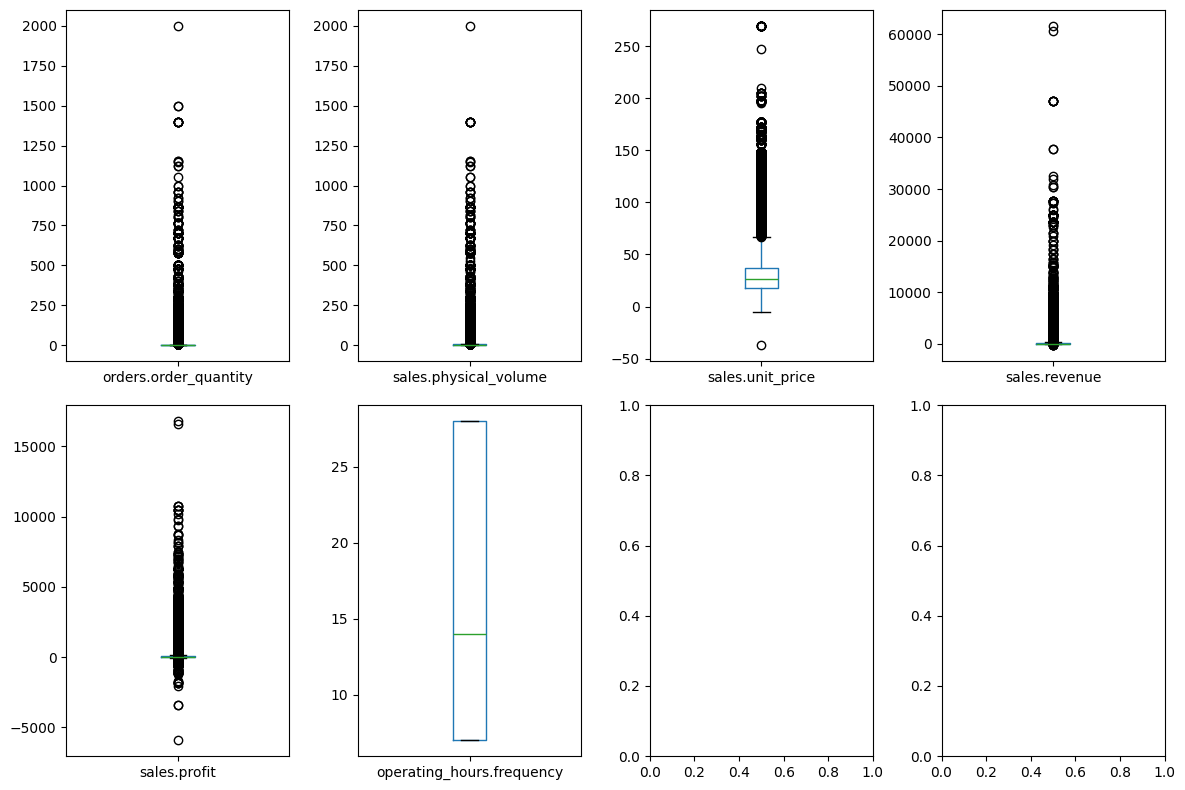

In [27]:
# Define figure layout
rows, columns = 2, 4
fig, axes = plt.subplots(rows, columns, figsize=(12, 8))
flat_axes = axes.flat

# Plot boxplots for each numerical column in all datasets
ctr = 0
for table_name, table_df in numerical_datasets.items():
    pdf = table_df.toPandas()

    for col_name in pdf.columns:
        temp_df = pdf[[col_name]]
        temp_df.columns = [f"{table_name}.{col_name}"]
        temp_df.boxplot(grid=False, ax=flat_axes[ctr])
        ctr += 1

# Adjust layout and display
plt.tight_layout()
plt.show()

# Clean up temporary variable
del numerical_datasets

In [28]:
# Display dataset summary
summarize_datasets(datasets)

DataFrame[table: string, column: string, count: string, mean: string, stddev: string, min: string, 25%: string, 50%: string, 75%: string, max: string, null_like: string]

In [ ]:
# Filter visit_plan dataset to only include records before or on 2026-01-01
datasets["visit_plan"] = datasets["visit_plan"].filter(
    col("anchor_date") <= "2026-01-01"
)

# Display dataset summary
summarize_datasets(datasets)

[Stage 210:>                                                        (0 + 8) / 8]

# Feature Engineering

In [ ]:
# Join operating_hours with customers to get location information
location_df = (
    datasets["operating_hours"]
    .join(
        datasets["customers"].select("customer_id", "sales_office_location"),
        on="customer_id",
        how="inner",
    )
)

# Combine all locations across datasets and collect unique set
locations_row = (
    location_df.select("sales_office_location")
    .unionByName(datasets["visit_plan"].select("sales_office_location"))
    .unionByName(datasets["cutoff_times"].select("sales_office_location"))
    .where(col("sales_office_location").isNotNull())
    .agg(collect_set("sales_office_location").alias("locations"))
    .collect()[0]
)

# Extract set of unique locations
locations = set(locations_row["locations"])
print(locations)

In [ ]:
tz_map = {
    # Arizona - Mountain
    "Chinle, AZ": "America/Phoenix",
    "Cochise, AZ": "America/Phoenix",
    "Flagstaff, AZ": "America/Phoenix",
    "Glendale, AZ": "America/Phoenix",
    "Huachuca City, AZ": "America/Phoenix",
    "Kingman, AZ": "America/Phoenix",
    "Prescott, AZ": "America/Phoenix",
    "Show Low, AZ": "America/Phoenix",
    "Tempe, AZ": "America/Phoenix",
    "Tucson, AZ": "America/Phoenix",
    "Yuma, AZ": "America/Phoenix",

    # Colorado - Mountain
    "Alamosa, CO": "America/Denver",
    "Colorado Springs, CO": "America/Denver",
    "Denver, CO": "America/Denver",
    "Glenwood Springs, CO": "America/Denver",
    "Glenwood, CO": "America/Denver",
    "Grand Junction, CO": "America/Denver",
    "Johnstown, CO": "America/Denver",
    "Pueblo, CO": "America/Denver",

    # Idaho - mostly Mountain
    "Boise, ID": "America/Denver",
    "Idaho Falls, ID": "America/Denver",
    "Lewiston, ID": "America/Los_Angeles",
    "Pocatello, ID": "America/Denver",
    "Twin Falls, ID": "America/Denver",

    # Nebraska - Central
    "Scottsbluff, NE": "America/Chicago",

    # Nevada - Pacific
    "Elko, NV": "America/Los_Angeles",
    "Reno, NV": "America/Los_Angeles",

    # New Mexico - Mountain
    "Albuquerque, NM": "America/Denver",

    # Oregon - Pacific
    "Bend, OR": "America/Los_Angeles",
    "Eugene, OR": "America/Los_Angeles",
    "LaGrande, OR": "America/Los_Angeles",
    "Pendleton, OR": "America/Los_Angeles",
    "Wilsonville, OR": "America/Los_Angeles",

    # Utah - Mountain
    "Draper, UT": "America/Denver",
    "Logan, UT": "America/Denver",
    "Ogden, UT": "America/Denver",
    "Price, UT": "America/Denver",
    "Richfield, UT": "America/Denver",

    # Washington - Pacific
    "Arlington, WA": "America/Los_Angeles",
    "Bellevue, WA": "America/Los_Angeles",
    "Bremerton, WA": "America/Los_Angeles",
    "South Sound, WA": "America/Los_Angeles",
    "Spokane, WA": "America/Los_Angeles",
    "Tacoma, WA": "America/Los_Angeles",
    "Walla Walla, WA": "America/Los_Angeles",
    "Wenatchee, WA": "America/Los_Angeles",

    # Wyoming - Mountain
    "Cheyenne, WY": "America/Denver",
}


# Join operating_hours with customers and add UTC anchor timestamp
datasets["operating_hours"] = (
    datasets["operating_hours"]
    .join(
        datasets["customers"].select("customer_id", "sales_office_location"),
        on="customer_id",
        how="inner",
    )
    .transform(
        lambda df: add_ts_utc_by_location(
            table_df=df,
            tz_map=tz_map,
            date_col_name="anchor_date",
            location_col_name="sales_office_location",
        )
    )
    .select(
        "customer_id",
        "frequency",
        "sales_office_location",
        "delivery_day_of_week_name",
        "anchor_date",
        "anchor_ts_utc",
    )
)

# Preview operating_hours
display(datasets["operating_hours"].limit(3))

# Add UTC anchor timestamp to visit_plan, join cutoff_times, and standardize
datasets["visit_plan"] = (
    datasets["visit_plan"]
    .transform(
        lambda df: add_ts_utc_by_location(
            table_df=df,
            tz_map=tz_map,
            date_col_name="anchor_date",
            location_col_name="sales_office_location",
        )
    )
    .join(
        datasets["cutoff_times"].select(
            "sales_office_id",
            "distribution_mode",
            "cutoff_time",
        ),
        on=["sales_office_id", "distribution_mode"],
        how="left",
    )
    .fillna({"cutoff_time": "5:00:00 PM"})
    .select(
        "customer_id",
        "sales_office_id",
        "sales_office_location",
        "frequency",
        "distribution_mode",
        "shipping_duration",
        "shipping_destination",
        "cutoff_time",
        "anchor_day_of_week",
        "anchor_date",
        "anchor_ts_utc",
        "snapshot_date",
        "snapshot_ts_utc",
    )
)

# Preview visit_plan
display(datasets["visit_plan"].limit(3))

# Add quarter start for orders based on created_ts_utc
datasets["orders"] = datasets["orders"].withColumn(
    "order_quarter_start",
    date_trunc("quarter", col("created_ts_utc")),
)

# Preview orders
display(datasets["orders"].limit(3))

# Add quarter start for sales based on posting_ts
datasets["sales"] = datasets["sales"].withColumn(
    "quarter_start",
    date_trunc("quarter", col("posting_ts")),
)

# Preview sales
display(datasets["sales"].limit(3))

# Data Analysis

## Top 8 Events in Google Analytics

In [ ]:
# Count total number of events by event_name
event_counts = (
    datasets["google_analytics"]
    .groupBy("event_name")
    .agg(count_("*").alias("count"))
)

# Compute total count for percentage calculation
total_count = event_counts.agg({"count": "sum"}).collect()[0][0]

# Calculate event percentages and select top 8
top_events_ga = (
    event_counts
    .withColumn("percentage", (col("count") / total_count) * 100)
    .orderBy(col("percentage").desc())
    .limit(8)
)

# Convert Spark DataFrame to Pandas for visualization
top_events_pd = top_events_ga.toPandas()

# Plot bar chart of top events
top_events_pd.plot(
    kind="bar",
    x="event_name",
    y="percentage",
    title="Top 8 Google Analytics Events",
    xlabel="Event Name",
    ylabel="Percentage (%)",
    color="skyblue"
)

# Show the plot
plt.show()

## Top Events Split by Device Category

In [ ]:
# Identify top events by frequency
top_events_df: DataFrame = (
    datasets["google_analytics"]
    .groupBy("event_name")
    .agg(count(lit(1)).alias("count"))
    .orderBy(desc("count"))
    .limit(6)
    .select("event_name")
)

# Keep only rows from the top events
ga_top_df: DataFrame = datasets["google_analytics"].join(
    top_events_df, on="event_name", how="inner"
)

# Count events by device category
counts_df: DataFrame = ga_top_df.groupBy("event_name", "device_category").agg(
    count(lit(1)).alias("n")
)

# Pivot to wide format with device categories as columns
pivot_counts_df: DataFrame = (
    counts_df.groupBy("event_name").pivot("device_category").sum("n").fillna(0)
)

# Compute row-wise totals to derive percentages
device_cols: List[str] = [c for c in pivot_counts_df.columns if c != "event_name"]
row_total = None
for c in device_cols:
    row_total = col(c) if row_total is None else row_total + col(c)

pivot_pct_df: DataFrame = pivot_counts_df.withColumn(
    "row_total", coalesce(row_total, lit(0))
)

# Convert counts to percentages with two-decimal rounding
for c in device_cols:
    pct_col = col(c) / when(col("row_total") > 0, col("row_total")).otherwise(
        lit(1)
    ) * lit(100.0)
    pivot_pct_df = pivot_pct_df.withColumn(c, round_(pct_col, 2))

# Drop helper total column
pivot_pct_df = pivot_pct_df.drop("row_total")

# Reorder device columns for readability
desired_order: List[str] = ["desktop", "mobile", "tablet"]
ordered_cols: List[str] = ["event_name"] + [c for c in desired_order if c in device_cols]
remaining_cols: List[str] = [c for c in device_cols if c not in desired_order]
final_cols: List[str] = ordered_cols + remaining_cols
pivot_pct_df = pivot_pct_df.select(*final_cols)

# Preserve original top-event ordering
top_events_in_order: List[str] = [r["event_name"] for r in top_events_df.collect()]
mapping_rows: List[Tuple[str, int]] = [
    (name, idx) for idx, name in enumerate(top_events_in_order)
]
mapping_df: DataFrame = spark.createDataFrame(
    mapping_rows, ["event_name", "_sort_key"]
)

# Apply ordering based on mapping
pivot_pct_df = (
    pivot_pct_df.join(mapping_df, on="event_name", how="left")
    .orderBy(col("_sort_key"))
    .drop("_sort_key")
)

# Convert to pandas for plotting
ct_pd = pivot_pct_df.toPandas().set_index("event_name")

# Plot stacked horizontal bar chart
ax = ct_pd.plot(
    kind="barh",
    stacked=True,
    figsize=(9, 5),
    title="Event Distribution by Device Category (%)",
)
ax.set_xlabel("Percentage")
ax.set_ylabel("Event Name")
ax.set_xlim(0, 100)
plt.xticks(rotation=0)

# Place legend outside the plot
plt.legend(
    title="Device Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0.0,
)

# Finalize layout and show chart
plt.tight_layout()
plt.show()

## Total Orders by Quarter

In [ ]:
# Aggregate total orders by quarter
order_trend_q = (
    datasets["orders"]
    .groupBy("order_quarter_start")
    .agg(count_(lit(1)).alias("num_orders"))
    .orderBy(col("order_quarter_start").asc())
)

# Add readable quarter label
order_trend_q = order_trend_q.withColumn(
    "quarter_label",
    format_string(
        "%dQ%d",
        year(col("order_quarter_start")),
        quarter(col("order_quarter_start")),
    ),
)

# Convert Spark DataFrame to Pandas for plotting
order_trend_pd = order_trend_q.toPandas()

# Plot quarterly order trends
plt.figure(figsize=(10, 4))
plt.plot(
    order_trend_pd["order_quarter_start"],
    order_trend_pd["num_orders"],
    marker="o",
)

plt.title("Total Orders Quarterly")
plt.xlabel("Quarter")
plt.ylabel("Number of Orders")

# Format x-axis ticks with quarter labels
plt.xticks(
    ticks=order_trend_pd["order_quarter_start"],
    labels=order_trend_pd["quarter_label"],
    rotation=0,
)

plt.tight_layout()
plt.show()

##Revenue and Profit Quartarly

In [ ]:
# Aggregate revenue and profit by quarter
revenue_trend_q: DataFrame = (
    datasets["sales"]
    .groupBy("quarter_start")
    .agg(
        sum_("revenue").alias("revenue"),
        sum_("profit").alias("profit"),
    )
    .orderBy(col("quarter_start").asc())
)

# Build a readable quarter label like 2025Q3
revenue_trend_q = revenue_trend_q.withColumn(
    "quarter_label",
    format_string(
        "%dQ%d",
        year(col("quarter_start")),
        quarter(col("quarter_start")),
    ),
)

# Convert to pandas for plotting
revenue_trend_pd: pd.DataFrame = revenue_trend_q.toPandas()

# Initialize the figure
plt.figure(figsize=(10, 5))

# Plot revenue over time
plt.plot(
    revenue_trend_pd["quarter_start"],
    revenue_trend_pd["revenue"],
    marker="o",
    label="Revenue",
)

# Plot profit over time
plt.plot(
    revenue_trend_pd["quarter_start"],
    revenue_trend_pd["profit"],
    marker="o",
    label="Profit",
)

# Add titles and labels
plt.title("Revenue and Profit Quarterly")
plt.xlabel("Quarter")
plt.ylabel("Dollars")
plt.legend()

# Format the y-axis in millions
plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{x / 1_000_000:.1f}M")
)

# Use quarter labels on the x-axis
plt.xticks(
    ticks=revenue_trend_pd["quarter_start"],
    labels=revenue_trend_pd["quarter_label"],
    rotation=0,
)

# Finalize layout and render
plt.tight_layout()
plt.show()

## Top 10 Products by Revenue and Profit

In [ ]:
# Select minimal materials columns for join
materials_small_df: DataFrame = datasets["materials"].select(
    "material_id", "trademark"
)

# Join sales with materials to bring in trademark
sales_with_trademark_df: DataFrame = datasets["sales"].join(
    materials_small_df, on="material_id", how="left"
)

# Compute top trademarks by total revenue
top_revenue_df: DataFrame = (
    sales_with_trademark_df.groupBy("trademark")
    .agg(sum_("revenue").alias("total_revenue"))
    .orderBy(desc("total_revenue"))
    .limit(10)
)

# Convert to pandas and sort ascending for horizontal bar order
top_revenue_pdf: "pd.DataFrame" = top_revenue_df.toPandas().sort_values(
    "total_revenue", ascending=True
)

# Compute top trademarks by total profit
top_profit_df: DataFrame = (
    sales_with_trademark_df.groupBy("trademark")
    .agg(sum_("profit").alias("total_profit"))
    .orderBy(desc("total_profit"))
    .limit(10)
)

# Convert to pandas and sort ascending for horizontal bar order
top_profit_pdf: "pd.DataFrame" = top_profit_df.toPandas().sort_values(
    "total_profit", ascending=True
)

# Create side-by-side bar charts for revenue and profit
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot top revenue
axes[0].barh(
    top_revenue_pdf["trademark"], top_revenue_pdf["total_revenue"]
)
axes[0].set_title("Top 10 Products by Revenue")
axes[0].set_xlabel("Total Revenue")
axes[0].set_ylabel("Product Name")
axes[0].xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{x / 1_000_000:.1f}M")
)

# Plot top profit
axes[1].barh(top_profit_pdf["trademark"], top_profit_pdf["total_profit"])
axes[1].set_title("Top 10 Products by Profit")
axes[1].set_xlabel("Total Profit")
axes[1].set_ylabel("Product Name")
axes[1].xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{x / 1_000_000:.1f}M")
)

# Finalize layout and render
plt.tight_layout()
plt.show()

## Average Visit Frequency by Sales Office

In [ ]:
# Compute average visit frequency by sales office location
vp_avg = (
    datasets["visit_plan"]
    .groupBy("sales_office_location")
    .agg(avg(col("frequency")).alias("frequency"))
    .orderBy(asc("frequency"))
)

# Convert to Pandas for visualization
vp_avg_pd = vp_avg.toPandas()

# Create horizontal line plot
plt.figure(figsize=(10, 10))
plt.hlines(
    y=vp_avg_pd["sales_office_location"],
    xmin=0,
    xmax=vp_avg_pd["frequency"],
)
plt.plot(
    vp_avg_pd["frequency"],
    vp_avg_pd["sales_office_location"],
    "o",
)

# Add labels and title
plt.xlabel("Average Visit Frequency (Days)")
plt.title("Average Visit Frequency by Sales Office Location")

# Adjust layout and display
plt.tight_layout()
plt.show()

## Cutoff Time Counts

In [ ]:
# Prepare cutoff times DataFrame
cutoff_df: DataFrame = datasets["cutoff_times"]

# Parse cutoff time into timestamp
cutoff_df = cutoff_df.withColumn(
    "cutoff_ts",
    to_timestamp(col("cutoff_time"), "h:mm:ss a"),
)

# Count occurrences per timestamp
cutoff_counts: DataFrame = (
    cutoff_df.groupBy("cutoff_ts")
    .agg(count_(lit(1)).alias("count"))
)

# Determine min and max timestamps
min_time, max_time = (
    cutoff_counts.agg(min_("cutoff_ts"), max_("cutoff_ts")).first()
)

# Build a 30-minute interval time series between min and max
interval: timedelta = timedelta(minutes=30)
time_list: List[Tuple] = []
current = min_time
while current <= max_time:
    time_list.append((current,))
    current += interval

# Create a DataFrame of the full time series
time_df: DataFrame = cutoff_df.sparkSession.createDataFrame(
    time_list,
    ["cutoff_ts"],
)

# Left join counts onto the full time series and fill missing with 0
filled_df: DataFrame = (
    time_df.join(cutoff_counts, on="cutoff_ts", how="left")
    .fillna({"count": 0})
)

# Add a human-readable label and order chronologically
filled_df = filled_df.withColumn(
    "cutoff_label",
    date_format(col("cutoff_ts"), "h:mm a"),
).orderBy("cutoff_ts")

# Convert to pandas for plotting
cutoff_pd: "pd.DataFrame" = filled_df.toPandas()

# Plot frequency by cutoff time
plt.figure(figsize=(12, 5))
plt.bar(cutoff_pd["cutoff_label"], cutoff_pd["count"])
plt.title("Cutoff Time Frequency (Filled Every 30 Minutes)")
plt.xlabel("Cutoff Time")
plt.ylabel("Count of Records")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Abandoment Rate by Device

In [ ]:
# Normalize event names
ga_norm: DataFrame = datasets["google_analytics"].withColumn(
    "event_name_norm", lower(col("event_name"))
)

# Derive event day from UTC timestamp
ga_day: DataFrame = ga_norm.withColumn(
    "event_date_day", to_date(col("event_ts_utc"))
)

# Keep rows with required fields present
ga_day = ga_day.filter(
    col("customer_id").isNotNull()
    & col("event_date_day").isNotNull()
    & col("device_category").isNotNull()
    & col("event_name_norm").isNotNull()
)

# Collect events per customer, day, and device
daily_device: DataFrame = (
    ga_day.groupBy("customer_id", "event_date_day", "device_category")
    .agg(collect_list("event_name_norm").alias("event_name_list"))
)

# Flag conversion milestones and abandonment
daily_device = (
    daily_device
    .withColumn("added_to_cart", array_contains(col("event_name_list"), "add_to_cart"))
    .withColumn("purchased", array_contains(col("event_name_list"), "purchase"))
    .withColumn("abandoned", col("added_to_cart") & (~col("purchased")))
)

# Aggregate added-to-cart and abandoned counts by device
abandon_by_device: DataFrame = (
    daily_device.groupBy("device_category")
    .agg(
        sum_(when(col("added_to_cart"), 1).otherwise(0)).alias("added_to_cart"),
        sum_(when(col("abandoned"), 1).otherwise(0)).alias("abandoned"),
    )
)

# Compute abandonment rate with safe divide
abandon_by_device = abandon_by_device.withColumn(
    "abandon_rate",
    when(col("added_to_cart") == 0, lit(None).cast("double")).otherwise(
        col("abandoned") / col("added_to_cart")
    ),
)

# Order by highest abandonment rate
abandon_by_device = abandon_by_device.orderBy(col("abandon_rate").desc())

# Display results
display(abandon_by_device)

In [ ]:
# Convert Spark DataFrame to Pandas for visualization
abandon_by_device_pd: pd.DataFrame = (
    abandon_by_device.select("device_category", "abandon_rate").toPandas()
)

# Sort by abandonment rate descending
abandon_by_device_pd = abandon_by_device_pd.sort_values(
    "abandon_rate", ascending=False
)

# Create bar chart
plt.figure(figsize=(8, 5))
plt.bar(
    abandon_by_device_pd["device_category"],
    abandon_by_device_pd["abandon_rate"],
)

# Add title and axis labels
plt.title("Cart Abandonment Rate by Device")
plt.xlabel("Device Type")
plt.ylabel("Abandonment Rate")

# Format y-axis as percentage
plt.ylim(0, 1)
plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{x:.0%}")
)

# Optimize layout and display
plt.tight_layout()
plt.show()

## Event Counts by Device Properties

In [ ]:
# Define columns to visualize
columns_to_plot: List[str] = [
    "device_category",
    "device_operating_system",
    "device_mobile_brand_name",
]

# Create subplot layout
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 20))

# Generate plots for each selected column
for plot_index, plot_col in enumerate(columns_to_plot):
    counts_df: DataFrame = (
        datasets["google_analytics"]
        .filter(col(plot_col).isNotNull())
        .groupBy(plot_col)
        .agg(count(lit(1)).alias("event_count"))
        .orderBy(col("event_count").desc())
    )

    counts_pd: pd.DataFrame = counts_df.toPandas()
    ax = axes[plot_index]

    # Create bar plot
    ax.bar(counts_pd[plot_col], counts_pd["event_count"], color="skyblue")

    # Add title and axis labels
    title_text = f"Google Analytics Events by {plot_col.replace('_', ' ').title()}"
    ax.set_title(title_text)
    ax.set_xlabel(plot_col)
    ax.set_ylabel("Event Count")

    # Rotate x-axis labels and adjust margins
    ax.tick_params(axis="x", labelrotation=45)
    ax.margins(x=0.01)

# Adjust layout and display
plt.tight_layout()
plt.show()

## Google Analytics Events Over Time

In [ ]:
# Compute day-of-week (Mon=0) for Google Analytics events
ga_events_by_day_df = datasets["google_analytics"].withColumn(
    "day_of_week_spark", dayofweek(col("event_ts_utc"))
)
ga_events_by_day_df = ga_events_by_day_df.withColumn(
    "day_of_week_mon0", (col("day_of_week_spark") + 5) % 7
)

# Aggregate event counts by day-of-week and convert to Pandas
ga_day_counts_df = (
    ga_events_by_day_df.groupBy("day_of_week_mon0")
    .agg(count(lit(1)).alias("count"))
    .orderBy("day_of_week_mon0")
)
ga_day_counts_pd: pd.DataFrame = ga_day_counts_df.toPandas()

# Map numeric day index to short day name
day_name_map: Dict[int, str] = {
    0: "Mon",
    1: "Tue",
    2: "Wed",
    3: "Thu",
    4: "Fri",
    5: "Sat",
    6: "Sun",
}
ga_day_counts_pd["day_name"] = ga_day_counts_pd["day_of_week_mon0"].map(
    day_name_map
)

# Compute fractional hour-of-day for Google Analytics events and convert to Pandas
ga_hours_df = datasets["google_analytics"].withColumn(
    "hour_of_day",
    hour(col("event_ts_utc")) + (minute(col("event_ts_utc")) / 60.0),
)
ga_hours_sr: pd.Series = ga_hours_df.select("hour_of_day").toPandas()[
    "hour_of_day"
]

# Compute day-of-week (Mon=0) for Orders
orders_by_day_df = datasets["orders"].withColumn(
    "day_of_week_spark", dayofweek(col("created_ts_utc"))
)
orders_by_day_df = orders_by_day_df.withColumn(
    "day_of_week_mon0", (col("day_of_week_spark") + 5) % 7
)

# Aggregate order counts by day-of-week and convert to Pandas
orders_day_counts_df = (
    orders_by_day_df.groupBy("day_of_week_mon0")
    .agg(count(lit(1)).alias("count"))
    .orderBy("day_of_week_mon0")
)
orders_day_counts_pd: pd.DataFrame = orders_day_counts_df.toPandas()
orders_day_counts_pd["day_name"] = orders_day_counts_pd[
    "day_of_week_mon0"
].map(day_name_map)

# Compute fractional hour-of-day for Orders and convert to Pandas
orders_hours_df = datasets["orders"].withColumn(
    "hour_of_day",
    hour(col("created_ts_utc")) + (minute(col("created_ts_utc")) / 60.0),
)
orders_hours_sr: pd.Series = orders_hours_df.select("hour_of_day").toPandas()[
    "hour_of_day"
]

# Create 2x2 subplot layout for day-of-week and hour-of-day views
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Google Analytics: Events per Day of Week
axes[0, 0].bar(ga_day_counts_pd["day_name"], ga_day_counts_pd["count"])
axes[0, 0].set_title("Google Analytics: Events per Day of Week")
axes[0, 0].set_xlabel("Day of Week")
axes[0, 0].set_ylabel("Count")

# Google Analytics: Events per Hour of Day
axes[0, 1].hist(ga_hours_sr, bins=24, range=(0, 24))
axes[0, 1].set_title("Google Analytics: Events per Hour of Day")
axes[0, 1].set_xlabel("Hour of Day")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_xticks(range(0, 25, 2))

# Orders: Count per Day of Week
axes[1, 0].bar(orders_day_counts_pd["day_name"], orders_day_counts_pd["count"])
axes[1, 0].set_title("Orders: Count per Day of Week")
axes[1, 0].set_xlabel("Day of Week")
axes[1, 0].set_ylabel("Count")

# Orders: Count per Hour of Day
axes[1, 1].hist(orders_hours_sr, bins=24, range=(0, 24))
axes[1, 1].set_title("Orders: Count per Hour of Day")
axes[1, 1].set_xlabel("Hour of Day")
axes[1, 1].set_ylabel("Count")
axes[1, 1].set_xticks(range(0, 25, 2))

# Optimize spacing and display
plt.tight_layout()
plt.show()

## Sales Over Time

In [ ]:
# Add weekday columns to sales dataset
sales_with_days_df: DataFrame = datasets["sales"].withColumn(
    "day_of_week_spark", dayofweek(col("posting_ts"))
)
sales_with_days_df = sales_with_days_df.withColumn(
    "day_of_week_mon0", (col("day_of_week_spark") + 5) % 7
)

# Count sales by weekday (Monday=0)
sales_day_counts_df: DataFrame = (
    sales_with_days_df.groupBy("day_of_week_mon0")
    .agg(count_(lit(1)).alias("sales_count"))
    .orderBy("day_of_week_mon0")
)

# Convert to Pandas for plotting
sales_day_counts_pd: pd.DataFrame = sales_day_counts_df.toPandas()

# Map numeric weekdays to names
weekday_name_map: Dict[int, str] = {
    0: "Mon",
    1: "Tue",
    2: "Wed",
    3: "Thu",
    4: "Fri",
    5: "Sat",
    6: "Sun",
}
sales_day_counts_pd["day_name"] = sales_day_counts_pd["day_of_week_mon0"].map(
    weekday_name_map
)

# Plot sales count per day of week
plt.figure(figsize=(10, 5))
plt.bar(
    sales_day_counts_pd["day_name"],
    sales_day_counts_pd["sales_count"],
    color="seagreen",
)

# Add title and labels
plt.title("Sales by Day of Week (Posting Timestamp)")
plt.xlabel("Day of Week")
plt.ylabel("Sales Count")

# Optimize layout and display
plt.tight_layout()
plt.show()

## Order Type Counts

In [ ]:
# Count orders by type and convert to Pandas
order_type_counts_df: DataFrame = (
    datasets["orders"]
    .filter(col("order_type").isNotNull())
    .groupBy("order_type")
    .agg(count(lit(1)).alias("count"))
    .orderBy(col("count").desc())
)

# Convert to Pandas for visualization
order_type_counts_pd: pd.DataFrame = order_type_counts_df.toPandas()

# Create bar chart
plt.figure(figsize=(10, 5))
plt.bar(
    order_type_counts_pd["order_type"],
    order_type_counts_pd["count"],
    color="skyblue",
)

# Add title and axis labels
plt.title("Order Type Counts")
plt.xlabel("Order Type")
plt.ylabel("Count")

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha="right")

# Optimize layout and display
plt.tight_layout()
plt.show()

## Revenute, Profit and Volume Distributions

In [ ]:
# Select and clean numeric columns from the sales dataset
sales_df: DataFrame = datasets["sales"].select(
    "profit", "revenue", "physical_volume"
).dropna()

# Convert to Pandas for visualization
sales_pd: pd.DataFrame = sales_df.toPandas()

# Create subplots for each variable
fig, axes = plt.subplots(3, 1, figsize=(10, 8))

# Define columns to plot
numeric_columns: List[str] = ["profit", "revenue", "physical_volume"]

# Plot box and whisker charts for each metric
for i, column_name in enumerate(numeric_columns):
    axes[i].boxplot(sales_pd[column_name].dropna(), vert=False)
    axes[i].set_xlabel(column_name)
    axes[i].set_ylabel("Amount")
    axes[i].set_title(f"Box and Whisker Plot for {column_name}")

# Adjust layout and display
plt.tight_layout()
plt.show()

## Distribution Mode Counts

In [ ]:
# Compute record counts by distribution mode
distribution_counts_df: DataFrame = (
    datasets["cutoff_times"]
    .filter(col("distribution_mode").isNotNull())
    .groupBy("distribution_mode")
    .agg(count(lit(1)).alias("record_count"))
    .orderBy(col("record_count").desc())
)

# Convert Spark DataFrame to Pandas for plotting
distribution_counts_pd: pd.DataFrame = distribution_counts_df.toPandas()

# Create bar chart for distribution mode frequency
plt.figure(figsize=(8, 5))
plt.bar(
    distribution_counts_pd["distribution_mode"],
    distribution_counts_pd["record_count"],
    color="skyblue",
)

# Add title and axis labels
plt.title("Frequency of Distribution Modes")
plt.xlabel("Distribution Mode")
plt.ylabel("Record Count")

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha="right")

# Adjust layout and display
plt.tight_layout()
plt.show()

## Clients per Sales Office

In [ ]:
# Count customers per sales office location
customer_counts_df: DataFrame = (
    datasets["customers"]
    .filter(col("sales_office_location").isNotNull())
    .groupBy("sales_office_location")
    .agg(count(lit(1)).alias("customer_count"))
    .orderBy(col("customer_count").desc())
)

# Convert Spark DataFrame to Pandas for plotting
customer_counts_pd: pd.DataFrame = customer_counts_df.toPandas()

# Create bar chart
plt.figure(figsize=(8, 5))
plt.bar(
    customer_counts_pd["sales_office_location"],
    customer_counts_pd["customer_count"],
    color="skyblue",
)

# Add title and axis labels
plt.title("Customers per Sales Office")
plt.xlabel("Sales Office")
plt.ylabel("Customer Count")
plt.xticks(rotation=45, ha="right")

# Optimize layout and display
plt.tight_layout()
plt.show()

## Cold Drink Channel Breakdown

In [ ]:
# Count cold drink channels and convert to Pandas
cold_drink_counts_df: DataFrame = (
    datasets["customers"]
    .filter(col("cold_drink_channel_description").isNotNull())
    .groupBy("cold_drink_channel_description")
    .agg(count(lit(1)).alias("channel_count"))
    .orderBy(col("channel_count").desc())
)

cold_drink_counts_pd: pd.DataFrame = cold_drink_counts_df.toPandas()

# Create bar chart for cold drink channel distribution
plt.figure(figsize=(8, 5))
plt.bar(
    cold_drink_counts_pd["cold_drink_channel_description"],
    cold_drink_counts_pd["channel_count"],
    color="skyblue",
)

# Add title and axis labels
plt.title("Cold Drink Channel Distribution")
plt.xlabel("Cold Drink Channel")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")

# Optimize layout and display
plt.tight_layout()
plt.show()

## Shipping Condition Counts

In [ ]:
# Count shipping durations and convert to Pandas
shipping_duration_counts_df: DataFrame = (
    datasets["customers"]
    .filter(col("shipping_duration").isNotNull())
    .groupBy("shipping_duration")
    .agg(count(lit(1)).alias("count"))
    .orderBy(col("count").desc())
)
shipping_duration_counts_pd: pd.DataFrame = (
    shipping_duration_counts_df.toPandas()
)

# Count shipping destinations and convert to Pandas
shipping_destination_counts_df: DataFrame = (
    datasets["customers"]
    .filter(col("shipping_destination").isNotNull())
    .groupBy("shipping_destination")
    .agg(count(lit(1)).alias("count"))
    .orderBy(col("count").desc())
)
shipping_destination_counts_pd: pd.DataFrame = (
    shipping_destination_counts_df.toPandas()
)

# Create side-by-side bar charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot shipping duration counts
axes[0].bar(
    shipping_duration_counts_pd["shipping_duration"],
    shipping_duration_counts_pd["count"],
    color="skyblue",
)
axes[0].set_title("Shipping Duration Counts")
axes[0].set_xlabel("Shipping Duration")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

# Plot shipping destination counts
axes[1].bar(
    shipping_destination_counts_pd["shipping_destination"],
    shipping_destination_counts_pd["count"],
    color="lightgreen",
)
axes[1].set_title("Shipping Destination Counts")
axes[1].set_xlabel("Shipping Destination")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)

# Adjust layout and display
plt.tight_layout()
plt.show()

## Trademark Category Counts

In [ ]:
# Compute trademark counts from the materials dataset
trademark_counts_df: DataFrame = (
    datasets["materials"]
    .filter(col("trademark").isNotNull())
    .groupBy("trademark")
    .agg(count(lit(1)).alias("count"))
    .orderBy(col("count").desc())
)

# Convert to Pandas for plotting
trademark_counts_pd: pd.DataFrame = trademark_counts_df.toPandas()

# Create bar chart for trademark category counts
plt.figure(figsize=(8, 5))
plt.bar(
    trademark_counts_pd["trademark"],
    trademark_counts_pd["count"],
    color="skyblue",
)

# Add chart title and labels
plt.title("Trademark Category Counts")
plt.xlabel("Trademark")
plt.ylabel("Count")

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha="right")

# Optimize layout and display chart
plt.tight_layout()
plt.show()

## Beverage Category Counts

In [ ]:
# Aggregate counts by beverage category
beverage_counts_df: DataFrame = (
    datasets["materials"]
    .filter(col("beverage_category").isNotNull())
    .groupBy("beverage_category")
    .agg(count(lit(1)).alias("count"))
    .orderBy(col("count").desc())
)

# Convert Spark DataFrame to Pandas for plotting
beverage_counts_pd: pd.DataFrame = beverage_counts_df.toPandas()

# Create bar chart for beverage category counts
plt.figure(figsize=(8, 5))
plt.bar(
    beverage_counts_pd["beverage_category"],
    beverage_counts_pd["count"],
    color="skyblue",
)

# Add chart title and axis labels
plt.title("Beverage Category Counts")
plt.xlabel("Beverage Category")
plt.ylabel("Count")

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha="right")

# Optimize layout and display
plt.tight_layout()
plt.show()

## Order Distribution by Order Type

In [ ]:
# Convert Spark DataFrame to Pandas for visualization
orders_pd: pd.DataFrame = (
    datasets["orders"]
    .select("order_type", "order_quantity")
    .dropna()
    .toPandas()
)

# Create box plot comparing order quantities by type
plt.figure(figsize=(8, 5))
sns.boxplot(
    x="order_type",
    y="order_quantity",
    data=orders_pd,
    color="skyblue"
)

# Add title and axis labels
plt.title("Order Quantity by Order Type")
plt.xlabel("Order Type")
plt.ylabel("Order Quantity")

# Rotate x-axis labels for readability
plt.xticks(rotation=45)

# Optimize layout and display
plt.tight_layout()
plt.show()

# Results

In [ ]:
spark.stop()

# Display total runtime
notebook_end_time = time.time()
total_runtime = notebook_end_time - notebook_start_time

# Format runtime nicely (H:M:S)
hours, rem = divmod(total_runtime, 3600)
minutes, seconds = divmod(rem, 60)
print(f"Total notebook runtime: {int(hours):02d}:{int(minutes):02d}:{int(seconds):02d}")